In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA



In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import os

In [4]:
os.getcwd()

'C:\\Users\\xnovaq.16\\Documents\\myenv\\Marketing_Project\\customer_segmentation_using_kmeans\\Marketing_analysis'

In [5]:
os.chdir("C:\\Users\\xnovaq.16\\Documents\\myenv\\Marketing_Project\\customer_segmentation_using_kmeans\\Marketing_analysis")

In [6]:
pwd

'C:\\Users\\xnovaq.16\\Documents\\myenv\\Marketing_Project\\customer_segmentation_using_kmeans\\Marketing_analysis'

In [7]:
df = pd.read_csv(r"Marketing_data.csv")
df.head(10)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
5,C10006,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.000000,0,8,1800.0,1400.057770,2407.246035,0.000000,12
6,C10007,627.260806,1.000000,7091.01,6402.63,688.38,0.000000,1.000000,1.000000,1.000000,0.000000,0,64,13500.0,6354.314328,198.065894,1.000000,12
7,C10008,1823.652743,1.000000,436.20,0.00,436.20,0.000000,1.000000,0.000000,1.000000,0.000000,0,12,2300.0,679.065082,532.033990,0.000000,12
8,C10009,1014.926473,1.000000,861.49,661.49,200.00,0.000000,0.333333,0.083333,0.250000,0.000000,0,5,7000.0,688.278568,311.963409,0.000000,12
9,C10010,152.225975,0.545455,1281.60,1281.60,0.00,0.000000,0.166667,0.166667,0.000000,0.000000,0,3,11000.0,1164.770591,100.302262,0.000000,12


In [8]:
df.shape

(8950, 18)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   str    
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHASES_TRX    

In [10]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


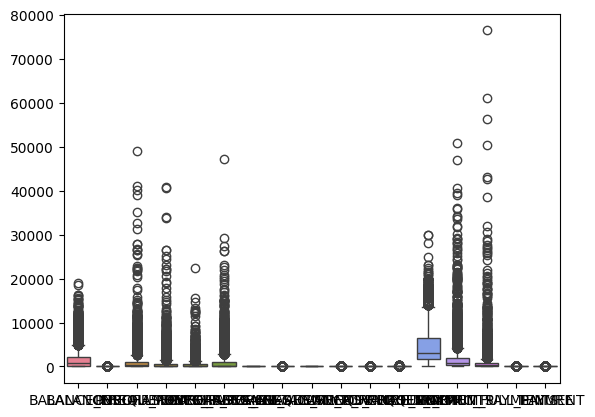

In [11]:
sns.boxplot(data = df)
plt.show()

In [12]:
skewed_cols = [
    'BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES', 
    'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE',
    'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS'
]
for col in skewed_cols:
    df[col + '_LOG'] = np.log1p(df[col])

df_original = df[skewed_cols].copy()
df = df.drop(columns=skewed_cols)

df.head()

,CUST_ID,BALANCE_FREQUENCY,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,PRC_FULL_PAYMENT,TENURE,BALANCE_LOG,PURCHASES_LOG,ONEOFF_PURCHASES_LOG,INSTALLMENTS_PURCHASES_LOG,CASH_ADVANCE_LOG,CREDIT_LIMIT_LOG,PAYMENTS_LOG,MINIMUM_PAYMENTS_LOG
0,C10001,0.818182,0.166667,0.000000,0.083333,0.000000,0,2,0.000000,12,3.735304,4.568506,0.000000,4.568506,0.000000,6.908755,5.312231,4.945277
1,C10002,0.909091,0.000000,0.000000,0.000000,0.250000,4,0,0.222222,12,8.071989,0.000000,0.000000,0.000000,8.770896,8.853808,8.319725,6.978531
2,C10003,1.000000,1.000000,1.000000,0.000000,0.000000,0,12,0.000000,12,7.822504,6.651791,6.651791,0.000000,0.000000,8.922792,6.434654,6.442994
3,C10004,0.636364,0.083333,0.083333,0.000000,0.083333,1,1,0.000000,12,7.419183,7.313220,7.313220,0.000000,5.331694,8.922792,0.000000,NaN
4,C10005,1.000000,0.083333,0.083333,0.000000,0.000000,0,1,0.000000,12,6.707735,2.833213,2.833213,0.000000,0.000000,7.090910,6.521114,5.504483


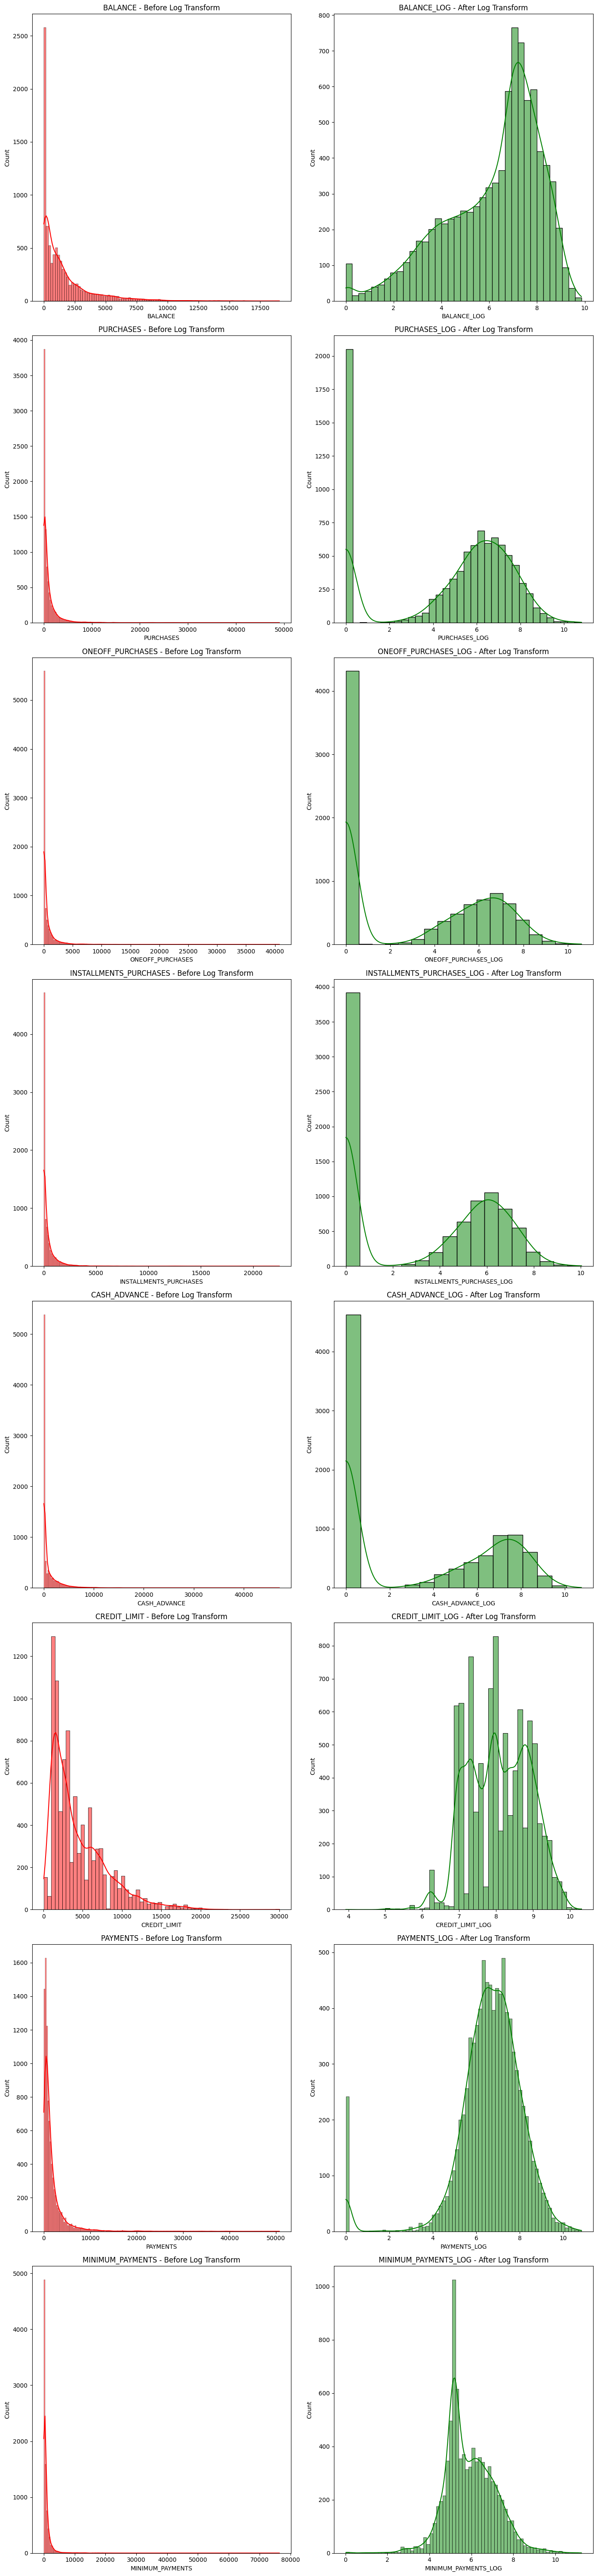

In [13]:
fig, axes = plt.subplots(len(skewed_cols), 2, figsize=(14, 60))

for i, col in enumerate(skewed_cols):
    # Before
    sns.histplot(df_original[col], ax=axes[i, 0], kde=True, color='red')
    axes[i, 0].set_title(f'{col} - Before Log Transform')
    
    # After
    sns.histplot(df[col + '_LOG'], ax=axes[i, 1], kde=True, color='green')
    axes[i, 1].set_title(f'{col}_LOG - After Log Transform')

plt.tight_layout()
plt.show()

In [14]:
df.head()

,CUST_ID,BALANCE_FREQUENCY,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,PRC_FULL_PAYMENT,TENURE,BALANCE_LOG,PURCHASES_LOG,ONEOFF_PURCHASES_LOG,INSTALLMENTS_PURCHASES_LOG,CASH_ADVANCE_LOG,CREDIT_LIMIT_LOG,PAYMENTS_LOG,MINIMUM_PAYMENTS_LOG
0,C10001,0.818182,0.166667,0.000000,0.083333,0.000000,0,2,0.000000,12,3.735304,4.568506,0.000000,4.568506,0.000000,6.908755,5.312231,4.945277
1,C10002,0.909091,0.000000,0.000000,0.000000,0.250000,4,0,0.222222,12,8.071989,0.000000,0.000000,0.000000,8.770896,8.853808,8.319725,6.978531
2,C10003,1.000000,1.000000,1.000000,0.000000,0.000000,0,12,0.000000,12,7.822504,6.651791,6.651791,0.000000,0.000000,8.922792,6.434654,6.442994
3,C10004,0.636364,0.083333,0.083333,0.000000,0.083333,1,1,0.000000,12,7.419183,7.313220,7.313220,0.000000,5.331694,8.922792,0.000000,NaN
4,C10005,1.000000,0.083333,0.083333,0.000000,0.000000,0,1,0.000000,12,6.707735,2.833213,2.833213,0.000000,0.000000,7.090910,6.521114,5.504483


In [15]:
df.isnull().sum()

CUST_ID                               0
BALANCE_FREQUENCY                     0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
PRC_FULL_PAYMENT                      0
TENURE                                0
BALANCE_LOG                           0
PURCHASES_LOG                         0
ONEOFF_PURCHASES_LOG                  0
INSTALLMENTS_PURCHASES_LOG            0
CASH_ADVANCE_LOG                      0
CREDIT_LIMIT_LOG                      1
PAYMENTS_LOG                          0
MINIMUM_PAYMENTS_LOG                313
dtype: int64

In [16]:
# Check who made one off purchase of approx.  $40761
df[(df.ONEOFF_PURCHASES_LOG == np.log1p(40761.250000))]

,CUST_ID,BALANCE_FREQUENCY,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,PRC_FULL_PAYMENT,TENURE,BALANCE_LOG,PURCHASES_LOG,ONEOFF_PURCHASES_LOG,INSTALLMENTS_PURCHASES_LOG,CASH_ADVANCE_LOG,CREDIT_LIMIT_LOG,PAYMENTS_LOG,MINIMUM_PAYMENTS_LOG
550,C10574,1.0,1.0,1.0,0.916667,0.083333,1,101,0.25,12,9.354313,10.800403,10.615512,9.021516,6.326448,10.021315,10.756446,7.998023


In [17]:
# Who made cash advance of $47000 and $48000
df[(df.CASH_ADVANCE_LOG >= np.log1p(47000)) & (df.CASH_ADVANCE_LOG <= np.log1p(48000))]

,CUST_ID,BALANCE_FREQUENCY,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,PRC_FULL_PAYMENT,TENURE,BALANCE_LOG,PURCHASES_LOG,ONEOFF_PURCHASES_LOG,INSTALLMENTS_PURCHASES_LOG,CASH_ADVANCE_LOG,CREDIT_LIMIT_LOG,PAYMENTS_LOG,MINIMUM_PAYMENTS_LOG
2159,C12226,1.0,0.583333,0.25,0.5,1.0,123,21,0.0,12,9.297073,6.070576,4.901564,5.701881,10.760839,9.883336,10.572588,8.59326


In [18]:
# Check for Null Values 
df.isna().sum()

CUST_ID                               0
BALANCE_FREQUENCY                     0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
PRC_FULL_PAYMENT                      0
TENURE                                0
BALANCE_LOG                           0
PURCHASES_LOG                         0
ONEOFF_PURCHASES_LOG                  0
INSTALLMENTS_PURCHASES_LOG            0
CASH_ADVANCE_LOG                      0
CREDIT_LIMIT_LOG                      1
PAYMENTS_LOG                          0
MINIMUM_PAYMENTS_LOG                313
dtype: int64

In [19]:
df.head()

,CUST_ID,BALANCE_FREQUENCY,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,PRC_FULL_PAYMENT,TENURE,BALANCE_LOG,PURCHASES_LOG,ONEOFF_PURCHASES_LOG,INSTALLMENTS_PURCHASES_LOG,CASH_ADVANCE_LOG,CREDIT_LIMIT_LOG,PAYMENTS_LOG,MINIMUM_PAYMENTS_LOG
0,C10001,0.818182,0.166667,0.000000,0.083333,0.000000,0,2,0.000000,12,3.735304,4.568506,0.000000,4.568506,0.000000,6.908755,5.312231,4.945277
1,C10002,0.909091,0.000000,0.000000,0.000000,0.250000,4,0,0.222222,12,8.071989,0.000000,0.000000,0.000000,8.770896,8.853808,8.319725,6.978531
2,C10003,1.000000,1.000000,1.000000,0.000000,0.000000,0,12,0.000000,12,7.822504,6.651791,6.651791,0.000000,0.000000,8.922792,6.434654,6.442994
3,C10004,0.636364,0.083333,0.083333,0.000000,0.083333,1,1,0.000000,12,7.419183,7.313220,7.313220,0.000000,5.331694,8.922792,0.000000,NaN
4,C10005,1.000000,0.083333,0.083333,0.000000,0.000000,0,1,0.000000,12,6.707735,2.833213,2.833213,0.000000,0.000000,7.090910,6.521114,5.504483


In [20]:
df['MINIMUM_PAYMENTS_LOG'].mean()

np.float64(5.922195186353701)

In [21]:
# Fill up the missing elements with mean of the 'MINIMUM_PAYMENT’ 
df['MINIMUM_PAYMENTS_LOG'] = df['MINIMUM_PAYMENTS_LOG'].fillna(df['MINIMUM_PAYMENTS_LOG'].mean(), inplace = True)
df['MINIMUM_PAYMENTS_LOG']

0       4.945277
1       6.978531
2       6.442994
3       5.922195
4       5.504483
          ...   
8945    3.909748
8946    5.922195
8947    4.423869
8948    4.038755
8949    4.491878
Name: MINIMUM_PAYMENTS_LOG, Length: 8950, dtype: float64

In [22]:
df['CREDIT_LIMIT_LOG'].mean()

np.float64(8.094834723530681)

In [23]:
df['CREDIT_LIMIT_LOG'].median()

np.float64(8.006700845440367)

In [24]:
# Fill up the missing elements with mean of the 'CREDIT_LIMIT’ 
df['CREDIT_LIMIT_LOG'] = df['CREDIT_LIMIT_LOG'].fillna(df['CREDIT_LIMIT_LOG'].mean(), inplace = True)
df['CREDIT_LIMIT_LOG']

0       6.908755
1       8.853808
2       8.922792
3       8.922792
4       7.090910
          ...   
8945    6.908755
8946    6.908755
8947    6.908755
8948    6.216606
8949    7.090910
Name: CREDIT_LIMIT_LOG, Length: 8950, dtype: float64

In [25]:
df.isnull().sum()

CUST_ID                             0
BALANCE_FREQUENCY                   0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
PRC_FULL_PAYMENT                    0
TENURE                              0
BALANCE_LOG                         0
PURCHASES_LOG                       0
ONEOFF_PURCHASES_LOG                0
INSTALLMENTS_PURCHASES_LOG          0
CASH_ADVANCE_LOG                    0
CREDIT_LIMIT_LOG                    0
PAYMENTS_LOG                        0
MINIMUM_PAYMENTS_LOG                0
dtype: int64

In [26]:
# Check duplicated entries in the data
print(df.duplicated().sum())

0


In [27]:
# Drop Customer ID since it has no meaning here 
df = df.drop(['CUST_ID'], axis = 1)


In [28]:
df.head(10)

,BALANCE_FREQUENCY,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,PRC_FULL_PAYMENT,TENURE,BALANCE_LOG,PURCHASES_LOG,ONEOFF_PURCHASES_LOG,INSTALLMENTS_PURCHASES_LOG,CASH_ADVANCE_LOG,CREDIT_LIMIT_LOG,PAYMENTS_LOG,MINIMUM_PAYMENTS_LOG
0,0.818182,0.166667,0.000000,0.083333,0.000000,0,2,0.000000,12,3.735304,4.568506,0.000000,4.568506,0.000000,6.908755,5.312231,4.945277
1,0.909091,0.000000,0.000000,0.000000,0.250000,4,0,0.222222,12,8.071989,0.000000,0.000000,0.000000,8.770896,8.853808,8.319725,6.978531
2,1.000000,1.000000,1.000000,0.000000,0.000000,0,12,0.000000,12,7.822504,6.651791,6.651791,0.000000,0.000000,8.922792,6.434654,6.442994
3,0.636364,0.083333,0.083333,0.000000,0.083333,1,1,0.000000,12,7.419183,7.313220,7.313220,0.000000,5.331694,8.922792,0.000000,5.922195
4,1.000000,0.083333,0.083333,0.000000,0.000000,0,1,0.000000,12,6.707735,2.833213,2.833213,0.000000,0.000000,7.090910,6.521114,5.504483
5,1.000000,0.666667,0.000000,0.583333,0.000000,0,8,0.000000,12,7.501540,7.196147,0.000000,7.196147,0.000000,7.496097,7.244983,7.786654
6,1.000000,1.000000,1.000000,1.000000,0.000000,0,64,1.000000,12,6.442955,8.866724,8.764620,6.535793,0.000000,9.510519,8.757047,5.293636
7,1.000000,1.000000,0.000000,1.000000,0.000000,0,12,0.000000,12,7.509145,6.080391,0.000000,6.080391,0.000000,7.741099,6.522189,6.278585
8,1.000000,0.333333,0.083333,0.250000,0.000000,0,5,0.000000,12,6.923556,6.759824,6.496005,5.303305,0.000000,8.853808,6.535645,5.746086
9,0.545455,0.166667,0.166667,0.000000,0.000000,0,3,0.000000,12,5.031914,7.156645,7.156645,0.000000,0.000000,9.305741,7.061138,4.618109


In [29]:
df.columns


Index(['BALANCE_FREQUENCY', 'PURCHASES_FREQUENCY',
       'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
       'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
       'PRC_FULL_PAYMENT', 'TENURE', 'BALANCE_LOG', 'PURCHASES_LOG',
       'ONEOFF_PURCHASES_LOG', 'INSTALLMENTS_PURCHASES_LOG',
       'CASH_ADVANCE_LOG', 'CREDIT_LIMIT_LOG', 'PAYMENTS_LOG',
       'MINIMUM_PAYMENTS_LOG'],
      dtype='str')

In [30]:
len(df.columns)

17

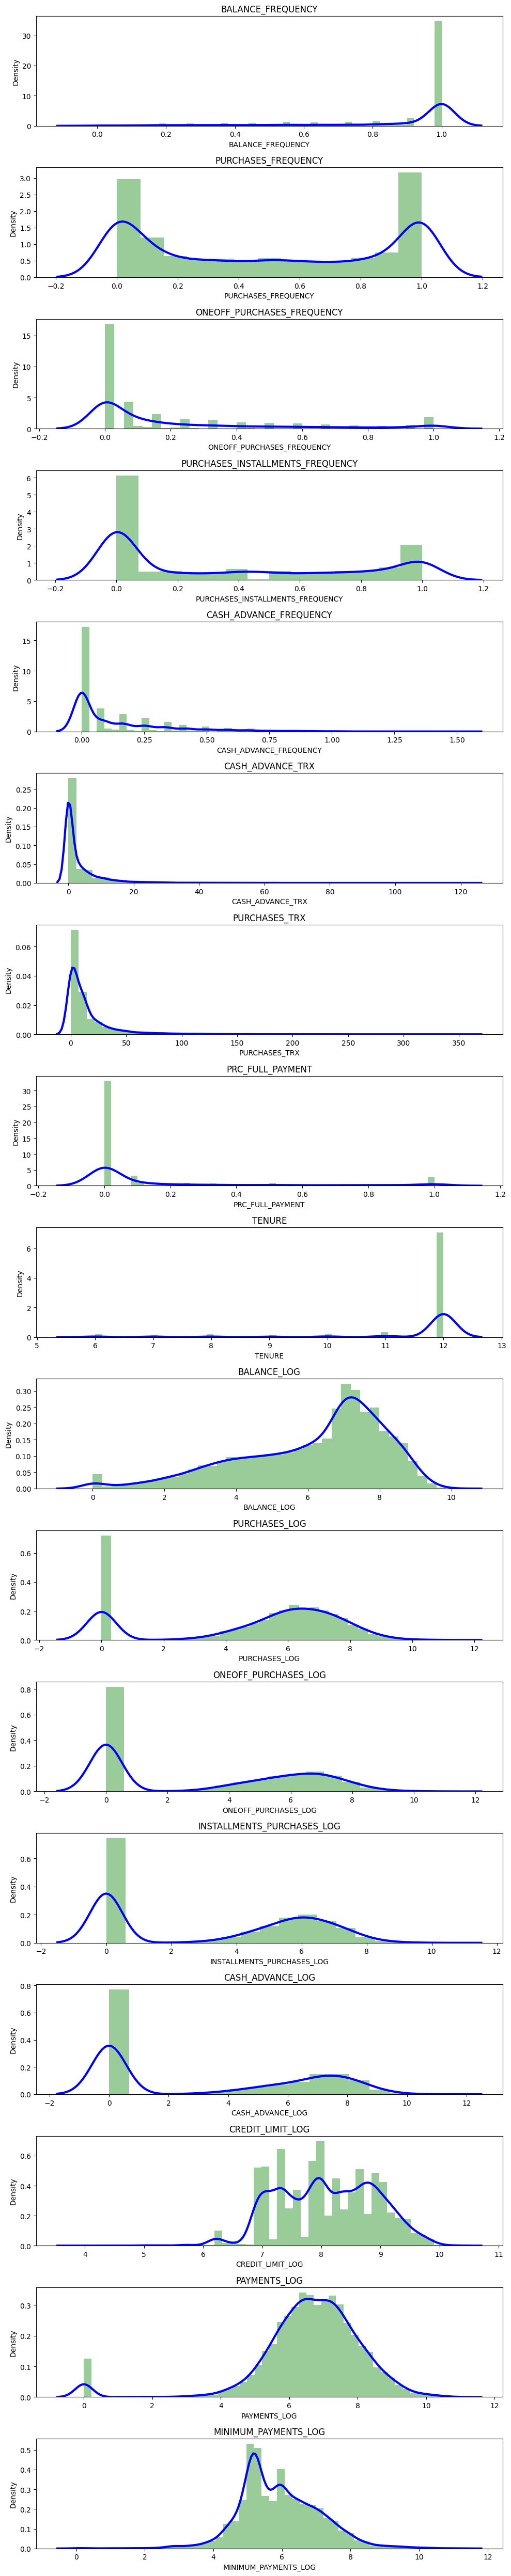

In [31]:
plt.figure(figsize = (10,50))
for i in range(len(df.columns)):
    plt.subplot(17, 1,i+1)
    sns.distplot(df[df.columns[i]], kde_kws = {"color":"b", "lw":3,"label": "KDE"}, hist_kws={"color": "g"})
    plt.title(df.columns[i])

plt.tight_layout()

In [32]:
df_corr = df.corr()
print(df_corr)

                                  BALANCE_FREQUENCY  PURCHASES_FREQUENCY  \
BALANCE_FREQUENCY                          1.000000             0.229715   
PURCHASES_FREQUENCY                        0.229715             1.000000   
ONEOFF_PURCHASES_FREQUENCY                 0.202415             0.501343   
PURCHASES_INSTALLMENTS_FREQUENCY           0.176079             0.862934   
CASH_ADVANCE_FREQUENCY                     0.191873            -0.308478   
CASH_ADVANCE_TRX                           0.141555            -0.203478   
PURCHASES_TRX                              0.189626             0.568430   
PRC_FULL_PAYMENT                          -0.095082             0.305802   
TENURE                                     0.119776             0.061506   
BALANCE_LOG                                0.652592            -0.093945   
PURCHASES_LOG                              0.096993             0.781750   
ONEOFF_PURCHASES_LOG                       0.140453             0.373634   
INSTALLMENTS

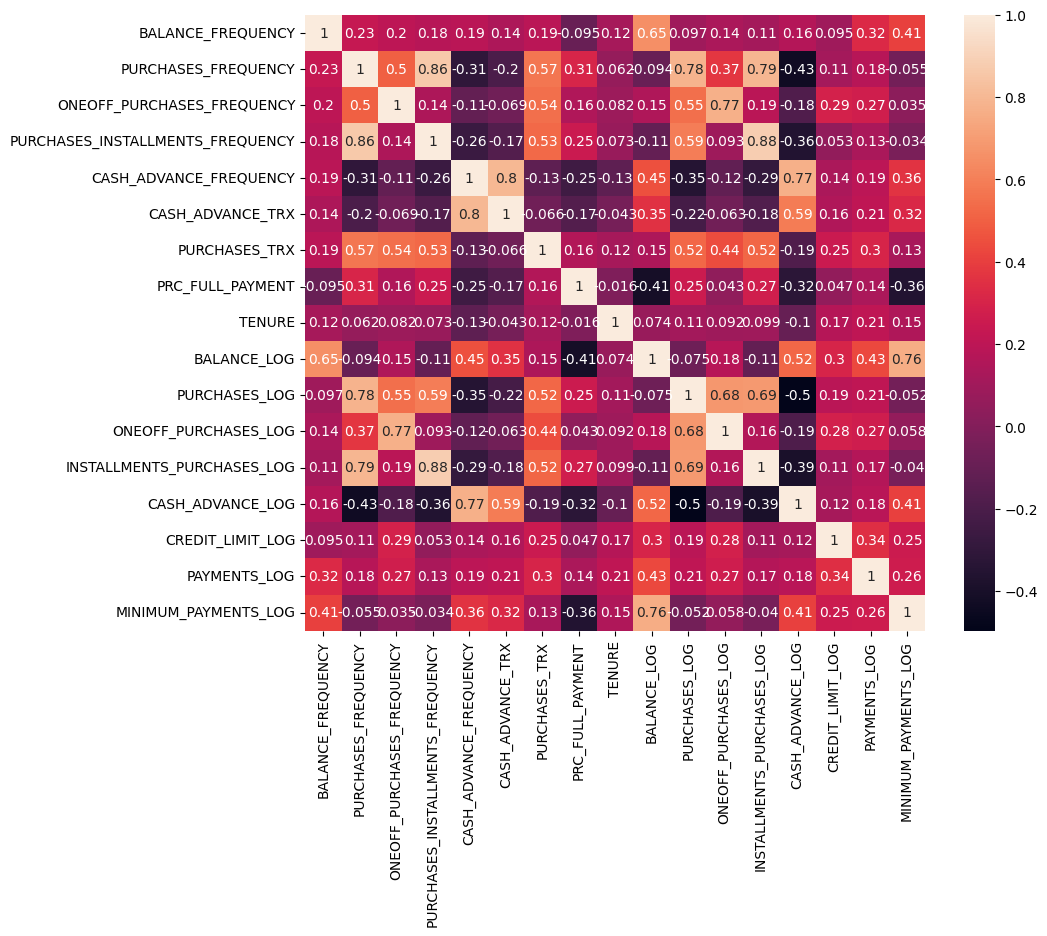

In [33]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_corr, annot = True) 
plt.show()

In [34]:
df

,BALANCE_FREQUENCY,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,PRC_FULL_PAYMENT,TENURE,BALANCE_LOG,PURCHASES_LOG,ONEOFF_PURCHASES_LOG,INSTALLMENTS_PURCHASES_LOG,CASH_ADVANCE_LOG,CREDIT_LIMIT_LOG,PAYMENTS_LOG,MINIMUM_PAYMENTS_LOG
0,0.818182,0.166667,0.000000,0.083333,0.000000,0,2,0.000000,12,3.735304,4.568506,0.000000,4.568506,0.000000,6.908755,5.312231,4.945277
1,0.909091,0.000000,0.000000,0.000000,0.250000,4,0,0.222222,12,8.071989,0.000000,0.000000,0.000000,8.770896,8.853808,8.319725,6.978531
2,1.000000,1.000000,1.000000,0.000000,0.000000,0,12,0.000000,12,7.822504,6.651791,6.651791,0.000000,0.000000,8.922792,6.434654,6.442994
3,0.636364,0.083333,0.083333,0.000000,0.083333,1,1,0.000000,12,7.419183,7.313220,7.313220,0.000000,5.331694,8.922792,0.000000,5.922195
4,1.000000,0.083333,0.083333,0.000000,0.000000,0,1,0.000000,12,6.707735,2.833213,2.833213,0.000000,0.000000,7.090910,6.521114,5.504483
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,1.000000,1.000000,0.000000,0.833333,0.000000,0,6,0.500000,6,3.384170,5.677165,0.000000,5.677165,0.000000,6.908755,5.788719,3.909748
8946,1.000000,1.000000,0.000000,0.833333,0.000000,0,6,0.000000,6,3.004851,5.707110,0.000000,5.707110,0.000000,6.908755,5.623517,5.922195
8947,0.833333,0.833333,0.000000,0.666667,0.000000,0,5,0.250000,6,3.194529,4.979489,0.000000,4.979489,0.000000,6.908755,4.410016,4.423869
8948,0.833333,0.000000,0.000000,0.000000,0.166667,2,0,0.250000,6,2.671218,0.000000,0.000000,0.000000,3.625907,6.216606,3.980615,4.038755


In [35]:
# Apply Feature Scaling .
scaler = StandardScaler()
df_standarized = scaler.fit_transform(df)


In [36]:
df_standarized.shape

(8950, 17)

In [37]:
display(pd.DataFrame(df_standarized))

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,-0.249434,-0.806490,-0.678661,-0.707313,-0.675349,-0.476070,-0.511333,-0.525551,0.360680,-1.205218,-0.113532,-0.987090,0.394480,-0.930733,-1.447175,-0.824484,-8.353848e-01
1,0.134325,-1.221758,-0.678661,-0.916995,0.573963,0.110074,-0.591796,0.234227,0.360680,0.948918,-1.679855,-0.987090,-1.087454,1.528788,0.926049,1.065033,9.032966e-01
2,0.518084,1.269843,2.673451,-0.916995,-0.675349,-0.476070,-0.109020,-0.525551,0.360680,0.824993,0.600727,1.062022,-1.087454,-0.930733,1.010218,-0.119300,4.453465e-01
3,-1.016953,-1.014125,-0.399319,-0.916995,-0.258913,-0.329534,-0.551565,-0.525551,0.360680,0.624653,0.827499,1.265778,-1.087454,0.564372,1.010218,-4.161996,-7.595016e-16
4,0.518084,-1.014125,-0.399319,-0.916995,-0.675349,-0.476070,-0.551565,-0.525551,0.360680,0.271260,-0.708481,-0.114307,-1.087454,-0.930733,-1.224922,-0.064979,-3.571956e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,0.518084,1.269843,-0.678661,1.179833,-0.675349,-0.476070,-0.350408,1.183951,-4.122768,-1.379634,0.266574,-0.987090,0.754107,-0.930733,-1.447175,-0.525121,-1.720890e+00
8946,0.518084,1.269843,-0.678661,1.179833,-0.675349,-0.476070,-0.350408,-0.525551,-4.122768,-1.568051,0.276841,-0.987090,0.763821,-0.930733,-1.447175,-0.628912,-7.595016e-16
8947,-0.185477,0.854576,-0.678661,0.760469,-0.675349,-0.476070,-0.390639,0.329200,-4.122768,-1.473834,0.027374,-0.987090,0.527794,-0.930733,-1.447175,-1.391318,-1.281253e+00
8948,-0.185477,-1.221758,-0.678661,-0.916995,0.157527,-0.182998,-0.591796,0.329200,-4.122768,-1.733775,-1.679855,-0.987090,-1.087454,0.086038,-2.291689,-1.661097,-1.610573e+00


In [38]:
# Identify the Optimum number of clusters ( Elbow method)
wcss = []
for k in range(1, 20):      
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(df_standarized)
    wcss.append(kmeans.inertia_)


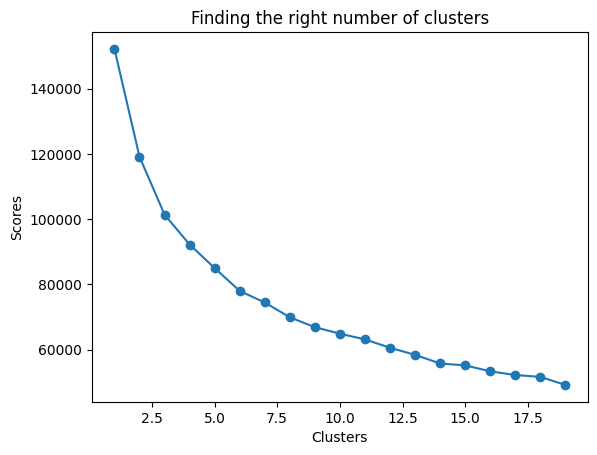

In [39]:
plt.plot(range(1,20), wcss, marker='o')
plt.xlabel("Clusters")
plt.ylabel("Scores")
plt.title("Finding the right number of clusters")
plt.show()

In [40]:
# Create the K Means Clustering Algorithm
kmeans = KMeans(6)
kmeans.fit(df_standarized)
y_kmeans = kmeans.labels_

In [41]:
kmeans.cluster_centers_.shape

(6, 17)

In [42]:
df['Cluster'] = kmeans.labels_

In [43]:
cluster_profile = df.groupby('Cluster').mean()
display(cluster_profile)


,BALANCE_FREQUENCY,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,PRC_FULL_PAYMENT,TENURE,BALANCE_LOG,PURCHASES_LOG,ONEOFF_PURCHASES_LOG,INSTALLMENTS_PURCHASES_LOG,CASH_ADVANCE_LOG,CREDIT_LIMIT_LOG,PAYMENTS_LOG,MINIMUM_PAYMENTS_LOG
Cluster,,,,,,,,,,,,,,,,,
0,0.982185,0.948739,0.652986,0.758214,0.047425,0.932986,52.562919,0.263603,11.902457,6.921894,7.928810,7.231267,6.547051,1.695741,8.706326,7.762375,6.128024
1,0.930664,0.017275,0.008712,0.007327,0.265614,5.507008,0.226680,0.031148,11.384727,7.278721,0.516065,0.350928,0.171925,6.869223,7.991884,6.667669,6.320158
2,0.943562,0.411220,0.339826,0.088298,0.054290,0.944678,8.410704,0.078849,11.638605,6.535018,6.163522,5.857014,1.642946,1.993537,8.017096,6.485551,5.907304
3,0.348105,0.274693,0.065552,0.197439,0.023998,0.458137,3.992474,0.213154,11.255880,2.669808,4.410506,2.164855,2.654571,1.162258,7.869229,5.057044,4.664011
4,0.936417,0.832416,0.041903,0.785135,0.024718,0.437214,14.997458,0.289466,11.454499,5.211597,6.203685,1.253910,6.101257,0.958218,7.727533,6.313515,5.557203
5,0.977328,0.550910,0.236421,0.387216,0.511101,15.990533,15.220118,0.035730,11.466272,8.087484,5.910955,4.417392,3.905809,8.024227,8.666852,7.679958,7.082360


In [44]:
cluster_names = {
    0: "Low spenders, low balance",
    1: "High cash advance users",
    2: "Installment buyers",
    3: "Big one-off purchasers",
    4: "Inactive / dormant users",
    5: "Full payment, high credit"
}

In [45]:
df['Cluster_Name'] = df['Cluster'].map(cluster_names)
df[['Cluster', 'Cluster_Name']].value_counts().sort_index()

Cluster  Cluster_Name             
0        Low spenders, low balance    1343
1        High cash advance users      2069
2        Installment buyers           1663
3        Big one-off purchasers       1063
4        Inactive / dormant users     1967
5        Full payment, high credit     845
Name: count, dtype: int64

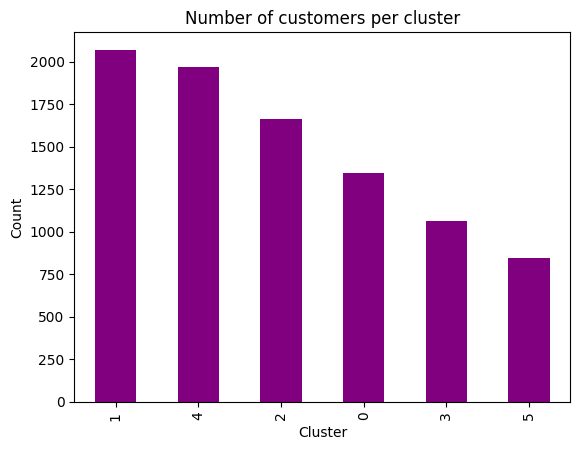

In [46]:
df['Cluster'].value_counts().plot(kind='bar', color='purple')
plt.title("Number of customers per cluster")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.savefig("Number of customers per cluster.jpg")
plt.show()

In [47]:
y_kmeans = kmeans.fit_predict(df_standarized)
display(y_kmeans)

array([0, 3, 2, ..., 1, 0, 2], shape=(8950,), dtype=int32)

In [48]:
# Silhouette Score: 0.204
# Score is low but acceptable for real-world high-dimensional customer data.
# Customer segments naturally overlap in behavior, making clean separation difficult.
from sklearn.metrics import silhouette_score
score = silhouette_score(df_standarized,y_kmeans)
print("Silhouette Score: ", score)


Silhouette Score:  0.20478471737023948


In [49]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(df_standarized)

# -1 means outliers in DBSCAN
print("Number of clusters found:", len(set(df['DBSCAN_Cluster'])) - 1)
print("Outliers found:", (df['DBSCAN_Cluster'] == -1).sum())

Number of clusters found: 27
Outliers found: 8047


In [50]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=6)
df['Agg_Cluster'] = agg.fit_predict(df_standarized)

In [51]:
from sklearn.metrics import silhouette_score

kmeans_score = silhouette_score(df_standarized, df['Cluster'])
agg_score = silhouette_score(df_standarized, df['Agg_Cluster'])

# DBSCAN only if it found valid clusters (exclude outliers)
dbscan_mask = df['DBSCAN_Cluster'] != -1
dbscan_score = silhouette_score(df_standarized[dbscan_mask], df['DBSCAN_Cluster'][dbscan_mask])

print(f"K-Means Silhouette Score:      {kmeans_score:.4f}")
print(f"Agglomerative Silhouette Score: {agg_score:.4f}")
print(f"DBSCAN Silhouette Score:        {dbscan_score:.4f}")

K-Means Silhouette Score:      0.2042
Agglomerative Silhouette Score: 0.1374
DBSCAN Silhouette Score:        0.0149


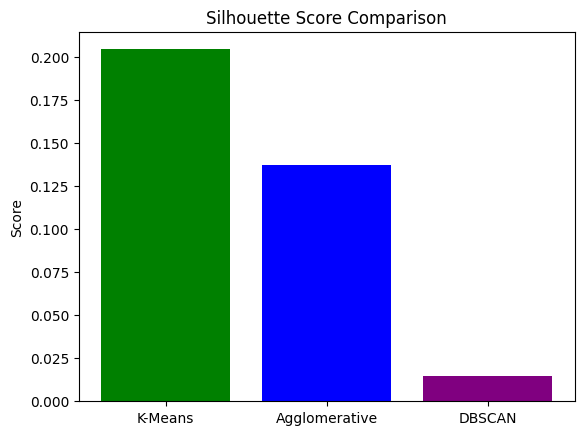

In [52]:
scores = {
    'K-Means': kmeans_score,
    'Agglomerative': agg_score,
    'DBSCAN': dbscan_score
}

plt.bar(scores.keys(), scores.values(), color=['green', 'blue', 'purple'])
plt.title("Silhouette Score Comparison")
plt.ylabel("Score")
plt.savefig("Silhouette Score Comparison.jpg")
plt.show()


In [53]:
# Apply PCA in the Data Set and create clusters 
pca = PCA(n_components=2)
principal_component = pca.fit_transform(df_standarized)
display(principal_component)

array([[-0.54985375, -2.54847692],
       [-2.94887651,  1.23121417],
       [ 1.35143066,  1.23009033],
       ...,
       [ 0.60182241, -3.27950592],
       [-2.65552264, -3.67587519],
       [-0.33868195, -0.90020877]], shape=(8950, 2))

In [54]:
# PCA was applied after clustering purely for visualization. 
# If I had applied PCA before clustering, I would have lost important information from the original 17 features, 
# which could have affected the quality of clusters.
print("Explained variance by each component:", pca.explained_variance_ratio_)
print("Total variance retained:", sum(pca.explained_variance_ratio_))

Explained variance by each component: [0.29866364 0.21846906]
Total variance retained: 0.5171326958474752


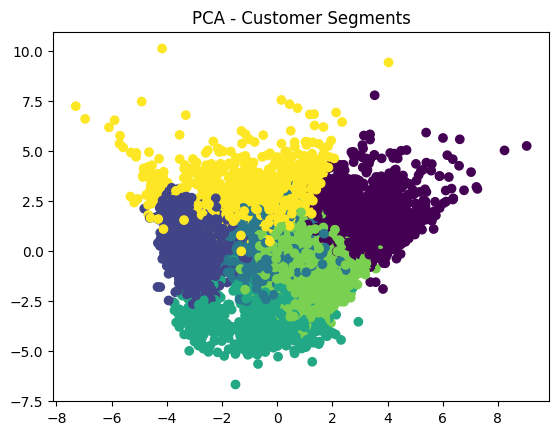

In [55]:
plt.scatter(principal_component[:, 0], principal_component[:, 1], c=df['Cluster'])
plt.title("PCA - Customer Segments")
plt.savefig("PCA - Customer Segments.jpg")
plt.show()


In [56]:
pca_df = pd.DataFrame(data = principal_component, columns =['pca1','pca2'])
pca_df.head()

,pca1,pca2
0,-0.549854,-2.548477
1,-2.948877,1.231214
2,1.351431,1.230090
3,-1.230682,-1.034955
4,-1.263213,-1.079272


In [57]:
pca_df = pd.concat([pca_df,pd.DataFrame({'cluster':y_kmeans})], axis = 1)
display(pca_df)

,pca1,pca2,cluster
0,-0.549854,-2.548477,0
1,-2.948877,1.231214,3
2,1.351431,1.230090,2
3,-1.230682,-1.034955,2
4,-1.263213,-1.079272,2
...,...,...,...
8945,1.381866,-2.934514,1
8946,0.930350,-2.178514,1
8947,0.601822,-3.279506,1
8948,-2.655523,-3.675875,0


In [58]:
pca_df.value_counts(pca_df.cluster)

cluster
3    2095
1    1941
2    1652
4    1310
0    1060
5     892
Name: count, dtype: int64

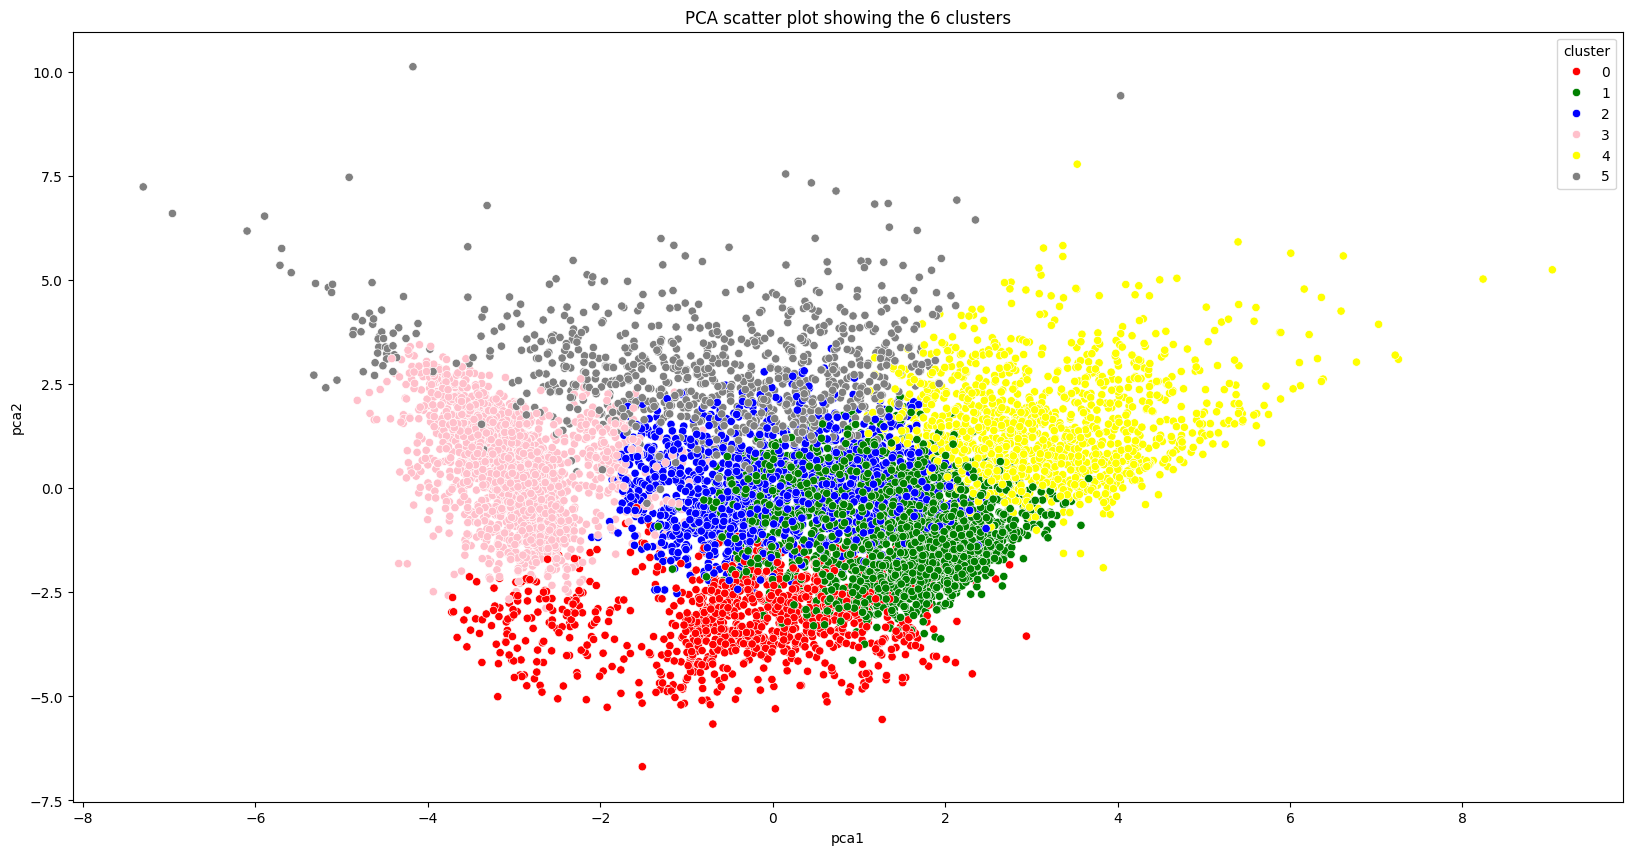

In [59]:
plt.figure(figsize=(20,10))
ax = sns.scatterplot(x="pca1", y="pca2", hue = "cluster", data = pca_df, palette =['red','green','blue','pink','yellow','gray','purple', 'black'])
plt.title("PCA scatter plot showing the 6 clusters")
plt.savefig("PCA scatter plot showing the 6 clusters.jpg")
plt.show()


In [60]:
import pickle

# Save all 3 files
pickle.dump(kmeans, open('kmeans_model.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))

print("Saved at:", os.getcwd())

print("Models saved successfully!")

Saved at: C:\Users\xnovaq.16\Documents\myenv\Marketing_Project\customer_segmentation_using_kmeans\Marketing_analysis
Models saved successfully!


In [61]:
import os
print(os.getcwd())

# Also check if pickle files actually exist
import os.path
print(os.path.exists('kmeans_model.pkl'))
print(os.path.exists('scaler.pkl'))

C:\Users\xnovaq.16\Documents\myenv\Marketing_Project\customer_segmentation_using_kmeans\Marketing_analysis
True
True
